# Panel Regression: ECB Shocks x Equity Duration



Dieses Notebook nutzt folgende Inputs:
- `intermediate/EQDuration_Macaulay.parquet`
- `intermediate/EQDuration_Netpayout.parquet`
- `intermediate/euro500_daily_returns.parquet`
- `tables/shocks_ecb_mpd_me_d.csv`

Wichtige Umsetzungen:
- Duration-Merge über `asof_effective_date` mit `last available <= event date` (nie vorwärts).
- `trbc_sector` wird aus den Duration-Inputs uebernommen.
- In den Regressionsbloecken am Ende von Step 5 werden `Financials` ausgeschlossen.

Ziel: Regression von Aktienreaktionen auf ECB-Schocks mit Interaktionen für Macaulay- und NP-Duration.


## 0.) Setup

In [13]:
import numpy as np
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

BASE_DIR = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data")
DATA_DIR = BASE_DIR / "intermediate"
TABLE_DIR = BASE_DIR / "tables"

DUR_PATH_MAC = DATA_DIR / "EQDuration_Macaulay.parquet"
DUR_PATH_NP = DATA_DIR / "EQDuration_Netpayout.parquet"
RET_PATH = DATA_DIR / "euro500_daily_returns.parquet"
SHK_PATH = DATA_DIR / "shocks_ecb_mpd_me_d.csv"

for p in [DUR_PATH_MAC, DUR_PATH_NP, RET_PATH, SHK_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required input: {p}")


## 1.) Helpers

In [14]:

def zscore_by_year(df: pd.DataFrame, col: str, year_col: str = "YEAR") -> pd.Series:
    def _z(s: pd.Series) -> pd.Series:
        mu = s.mean(skipna=True)
        sd = s.std(skipna=True, ddof=0)
        if pd.isna(sd) or sd == 0:
            return pd.Series(pd.NA, index=s.index)
        return (s - mu) / sd
    return df.groupby(year_col)[col].transform(_z)


def merge_last_available_feature(
    events: pd.DataFrame,
    features: pd.DataFrame,
    value_col: str,
    event_date_col: str = "date",
    feature_date_col: str = "asof_effective_date",
    key_priority=("RIC", "firm_id"),
):
    key = next((k for k in key_priority if k in events.columns and k in features.columns), None)
    if key is None:
        raise ValueError(f"No common key found between events and features (tried {key_priority})")

    left = events.copy()
    left[event_date_col] = pd.to_datetime(left[event_date_col], errors="coerce").dt.normalize()
    left["_row_order"] = np.arange(len(left))

    right = features[[key, feature_date_col, value_col]].copy()
    right[feature_date_col] = pd.to_datetime(right[feature_date_col], errors="coerce").dt.normalize()

    valid_left = left[event_date_col].notna() & left[key].notna()
    valid_right = right[feature_date_col].notna() & right[key].notna() & right[value_col].notna()

    l_ok = left.loc[valid_left].copy()
    r_ok = right.loc[valid_right].copy()

    parts = []
    for k_val, l_grp in l_ok.groupby(key, sort=False):
        r_grp = r_ok.loc[r_ok[key] == k_val]
        if r_grp.empty:
            l_grp = l_grp.copy()
            l_grp[value_col] = np.nan
            parts.append(l_grp)
            continue

        l_grp = l_grp.sort_values(event_date_col)
        r_grp = r_grp.sort_values(feature_date_col)

        m = pd.merge_asof(
            l_grp,
            r_grp,
            left_on=event_date_col,
            right_on=feature_date_col,
            direction="backward",
            allow_exact_matches=True,
        )
        if f"{key}_x" in m.columns:
            m[key] = m[f"{key}_x"]
            m = m.drop(columns=[c for c in [f"{key}_x", f"{key}_y"] if c in m.columns])
        parts.append(m)

    merged_ok = pd.concat(parts, axis=0, ignore_index=False, sort=False) if parts else l_ok.copy()

    left_bad = left.loc[~valid_left].copy()
    out = pd.concat([merged_ok, left_bad], axis=0, ignore_index=False, sort=False)
    out = out.sort_values("_row_order").drop(columns=["_row_order"], errors="ignore")
    out = out.drop(columns=[feature_date_col], errors="ignore")
    return out, key


def _cluster_groups(data: pd.DataFrame, date_col: str, firm_col: str) -> pd.DataFrame:
    d = data.copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    if d[date_col].isna().any():
        raise ValueError(f"NaT found in {date_col}")

    d[firm_col] = d[firm_col].astype(str).str.strip()
    if (d[firm_col] == "").any():
        raise ValueError(f"Empty values in {firm_col}")

    return pd.DataFrame(
        {
            "g_date": d[date_col].astype("int64"),
            "g_firm": d[firm_col].astype("category").cat.codes.astype("int64"),
        },
        index=d.index,
    )


def _full_rank_columns(X: pd.DataFrame, tol: float = 1e-12):
    cols = list(X.columns)
    if len(cols) <= 1:
        return cols

    keep = cols.copy()
    while len(keep) > 1:
        mat = X[keep].to_numpy(dtype=float)
        rank = np.linalg.matrix_rank(mat, tol=tol)
        if rank == len(keep):
            break
        variances = X[keep].var(axis=0, skipna=True).fillna(0.0)
        drop_col = variances.idxmin()
        keep.remove(drop_col)
    return keep


def fit_event_fe_2way(
    data: pd.DataFrame,
    y_col: str,
    x_cols: list,
    date_col: str = "date",
    firm_col: str = "firm_id",
    weights=None,
):
    cols = [y_col, date_col, firm_col] + x_cols
    d = data[cols].dropna().copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")

    if d.empty:
        raise ValueError("Empty regression sample after dropna.")

    for c in [y_col] + x_cols:
        c_dm = f"{c}__dm"
        d[c_dm] = d[c] - d.groupby(date_col)[c].transform("mean")

    y_dm = f"{y_col}__dm"
    x_dm = [f"{c}__dm" for c in x_cols]

    nonzero = []
    for c in x_dm:
        v = pd.to_numeric(d[c], errors="coerce").var(skipna=True)
        if pd.notna(v) and v > 1e-14:
            nonzero.append(c)

    if not nonzero:
        raise ValueError("No regressor variance left after event demeaning.")

    X = d[nonzero].astype(float)
    keep = _full_rank_columns(X)
    X = X[keep]
    y = d[y_dm].astype(float)

    groups = _cluster_groups(d, date_col=date_col, firm_col=firm_col)

    if weights is None:
        m = sm.OLS(y, X).fit(
            cov_type="cluster",
            cov_kwds={"groups": groups, "use_correction": True},
        )
    else:
        w = pd.Series(weights, index=data.index).reindex(d.index).astype(float)
        m = sm.WLS(y, X, weights=w).fit(
            cov_type="cluster",
            cov_kwds={"groups": groups, "use_correction": True},
        )

    name_map = {f"{c}__dm": c for c in x_cols}
    m.params.index = [name_map.get(i, i) for i in m.params.index]
    m.bse.index = [name_map.get(i, i) for i in m.bse.index]
    m.tvalues.index = [name_map.get(i, i) for i in m.tvalues.index]
    m.pvalues.index = [name_map.get(i, i) for i in m.pvalues.index]

    return m, d, keep


def apply_fdr(df: pd.DataFrame, p_col: str = "pvalue", term_col: str = "term") -> pd.DataFrame:
    out = df.copy()
    out["p_fdr"] = np.nan
    out["sig_fdr_5pct"] = False
    mask = out[p_col].notna() & out[term_col].str.contains("Duration", na=False)
    if mask.any():
        rej, p_adj = fdrcorrection(out.loc[mask, p_col].to_numpy(), alpha=0.05)
        out.loc[mask, "p_fdr"] = p_adj
        out.loc[mask, "sig_fdr_5pct"] = rej
    return out


def build_interactions(df: pd.DataFrame, dur_std: str, shock_spec: dict, include_mcap: bool = True, include_beta: bool = True):
    x_cols = []

    mp_col = shock_spec.get("mp")
    info_col = shock_spec.get("info")

    if mp_col is not None:
        x_cols.append(f"{mp_col}:{dur_std}")
        if include_beta:
            x_cols.append(f"{mp_col}:BETA_Y_std")
        if include_mcap:
            x_cols.append(f"{mp_col}:MCAP_Y_std")

    if info_col is not None:
        x_cols.append(f"{info_col}:{dur_std}")
        if include_beta:
            x_cols.append(f"{info_col}:BETA_Y_std")
        if include_mcap:
            x_cols.append(f"{info_col}:MCAP_Y_std")

    for c in x_cols:
        a, b = c.split(":")
        df[c] = pd.to_numeric(df[a], errors="coerce") * pd.to_numeric(df[b], errors="coerce")

    return df, x_cols


def assign_duration_bins_with_fallback(df: pd.DataFrame, dur_col: str, year_col: str = "YEAR"):
    d = df.copy()
    d[dur_col] = pd.to_numeric(d[dur_col], errors="coerce")

    stats = d.groupby(year_col)[dur_col].agg(n="count", nunique=lambda s: s.nunique(dropna=True)).reset_index()

    def qbin(s: pd.Series):
        x = pd.to_numeric(s, errors="coerce")
        ok = x.notna()
        out = pd.Series(pd.NA, index=s.index, dtype="object")
        if ok.sum() < 50 or x[ok].nunique() < 5:
            return out
        ranks = x[ok].rank(method="average")
        qcodes = pd.qcut(ranks, q=5, labels=False, duplicates="drop")
        if pd.Series(qcodes).nunique(dropna=True) < 5:
            return out
        labels = pd.Series(qcodes, index=ranks.index).map({0: "Q1", 1: "Q2", 2: "Q3", 3: "Q4", 4: "Q5"})
        out.loc[labels.index] = labels.astype("object")
        return out

    d["Dur_bin"] = d.groupby(year_col)[dur_col].transform(qbin)
    pass_share = float(d["Dur_bin"].isin(["Q1", "Q5"]).mean())

    fallback_used = False
    if pass_share < 0.05:
        fallback_used = True
        x = d[dur_col]
        ranks = x.rank(method="average")
        qcodes = pd.qcut(ranks, q=5, labels=False, duplicates="drop")
        labels = pd.Series(qcodes, index=d.index).map({0: "Q1", 1: "Q2", 2: "Q3", 3: "Q4", 4: "Q5"})
        d["Dur_bin"] = labels.astype("object")

    return d, stats, pass_share, fallback_used

## 2.) Load and clean shock data

In [15]:
df_shk = pd.read_csv(SHK_PATH).copy()
df_shk["date"] = pd.to_datetime(df_shk["date"], errors="coerce")
assert df_shk["date"].notna().all(), "Some shock dates could not be parsed."

# Load both PM and median shock variants for MP and Info
shock_candidates = {
    "MP_pm": ["MP_pm"],
    "MP_median": ["MP_median"],
    "Info_pm": ["CBI_pm"],
    "Info_median": ["CBI_median"],
}

shock_map = {}
missing = []
for target, candidates in shock_candidates.items():
    src = next((c for c in candidates if c in df_shk.columns), None)
    if src is None:
        missing.append(f"{target} <- {candidates}")
    else:
        shock_map[src] = target

if missing:
    raise ValueError("Missing required shock columns: " + "; ".join(missing))

df_shk = df_shk.rename(columns=shock_map)
for c in ["MP_pm", "MP_median", "Info_pm", "Info_median"]:
    df_shk[c] = pd.to_numeric(df_shk[c], errors="coerce")

SHOCK_COLUMNS = ["MP_pm", "MP_median", "Info_pm", "Info_median"]

df_shk = (
    df_shk[["date"] + SHOCK_COLUMNS]
    .dropna(subset=["date"] + SHOCK_COLUMNS)
    .drop_duplicates(subset=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

SHOCK_SPECS = [
    {"name": "TwoShock_pm", "mp": "MP_pm", "info": "Info_pm"},
    {"name": "MP_only_pm", "mp": "MP_pm", "info": None},
    {"name": "Info_only_pm", "mp": None, "info": "Info_pm"},
    {"name": "TwoShock_median", "mp": "MP_median", "info": "Info_median"},
    {"name": "MP_only_median", "mp": "MP_median", "info": None},
    {"name": "Info_only_median", "mp": None, "info": "Info_median"},
]

print("Shock sample:", df_shk.shape)
print("Shock columns:", SHOCK_COLUMNS)
print("Shock date range:", df_shk["date"].min(), "->", df_shk["date"].max())


Shock sample: (312, 5)
Shock columns: ['MP_pm', 'MP_median', 'Info_pm', 'Info_median']
Shock date range: 1999-01-07 00:00:00 -> 2025-10-30 00:00:00


## 3.) Load and clean duration panel

Duration panel sample (combined): (54455, 7)


,Variable,Coverage %,Non-missing,Total
0,Duration_Macaulay,81.46%,"44,358","54,455"
1,Duration_NetPayout,70.76%,"38,534","54,455"
2,MCAP_Q,99.16%,"54,000","54,455"
3,trbc_sector,99.16%,"54,000","54,455"


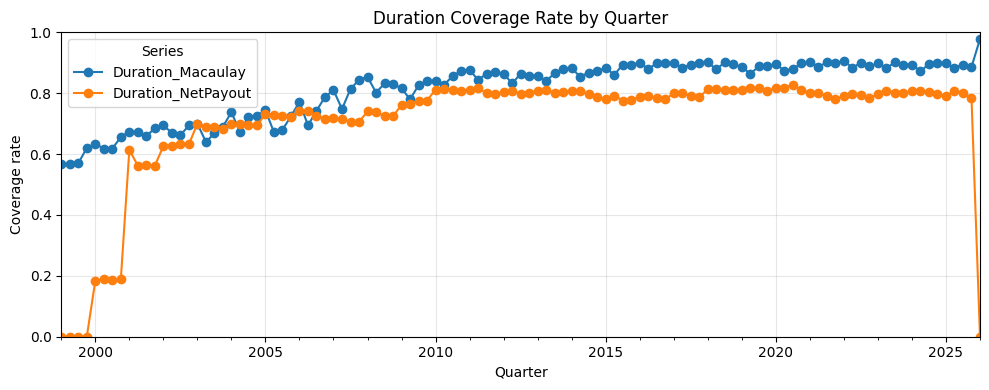

In [16]:
def prep_duration_quarter_panel(path: Path):
    d = pd.read_parquet(path).copy()

    if "status" in d.columns:
        d = d[d["status"].eq("ok")].copy()

    # Candidate source columns by target duration series
    duration_source_map = {
        "Duration_Macaulay": [
            "Duration_DCF_Macaulay_trim",
            "Duration_DCF_Macaulay",
        ],
        "Duration_NetPayout": [
            "Duration_NetPayout_trim",
            "Duration_NetPayout",
            "Duration_NP_trim",
            "Duration_NP",
            "NP_Duration",
        ],
    }

    selected = {}
    for out_col, candidates in duration_source_map.items():
        src = next((c for c in candidates if c in d.columns), None)
        if src is not None:
            d[out_col] = pd.to_numeric(d[src], errors="coerce")
            selected[out_col] = src

    if not selected:
        raise ValueError(f"No duration columns found in {path.name}")

    # Market-cap source from duration panel (predetermined control)
    mcap_candidates = [
        "mcap_eur", "MCAP_EURO", "marketcap", "market_cap", "mcap", "MarketCap", "market_cap_eur"
    ]
    mcap_source = next((c for c in mcap_candidates if c in d.columns), None)
    if mcap_source is not None:
        d["MCAP_Q"] = pd.to_numeric(d[mcap_source], errors="coerce")

    # Optional sector classifier from duration input table
    sector_candidates = ["trbc_sector", "TRBC_SECTOR", "trbc_economic_sector_name"]
    sector_source = next((c for c in sector_candidates if c in d.columns), None)
    if sector_source is not None:
        d["trbc_sector"] = d[sector_source].astype("string").str.strip()
        d["trbc_sector"] = d["trbc_sector"].replace("", pd.NA)

    if "RIC" in d.columns:
        d["RIC"] = d["RIC"].astype(str).str.strip()
    if "firm_id" in d.columns:
        d["firm_id"] = d["firm_id"].astype(str).str.strip()

    # Prefer true effective/as-of dates if available; YEAR is only a fallback.
    asof = None
    asof_source = None
    date_candidates = [
        "effective_date", "EffectiveDate", "effectiveDate", "effective_dt",
        "asof_date", "as_of_date", "AsOfDate",
        "date", "Date", "calc_date", "valuation_date",
    ]
    for c in date_candidates:
        if c in d.columns:
            dt = pd.to_datetime(d[c], errors="coerce")
            if dt.notna().any():
                asof = dt
                asof_source = c
                break

    if asof is None and "YEAR" in d.columns:
        asof = pd.to_datetime(pd.to_numeric(d["YEAR"], errors="coerce").astype("Int64").astype(str) + "-01-01", errors="coerce")
        asof_source = "YEAR->01-01"
    elif asof is None and "year" in d.columns:
        asof = pd.to_datetime(pd.to_numeric(d["year"], errors="coerce").astype("Int64").astype(str) + "-01-01", errors="coerce")
        asof_source = "year->01-01"
    elif asof is None:
        raise ValueError("Could not derive effective/as-of date for duration panel")

    d["asof_effective_date"] = asof.dt.normalize()

    key_cols = [c for c in ["RIC", "firm_id"] if c in d.columns]
    if not key_cols:
        raise ValueError("No key found for duration panel (need RIC or firm_id)")

    num_value_cols = list(selected.keys())
    if "MCAP_Q" in d.columns:
        num_value_cols.append("MCAP_Q")
    cat_value_cols = ["trbc_sector"] if "trbc_sector" in d.columns else []

    keep_cols = key_cols + ["asof_effective_date"] + num_value_cols + cat_value_cols
    d = d[keep_cols].dropna(subset=["asof_effective_date"]).copy()

    grp_keys = key_cols + ["asof_effective_date"]
    d_q_num = d.groupby(grp_keys, as_index=False)[num_value_cols].median() if num_value_cols else d[grp_keys].drop_duplicates().copy()

    if cat_value_cols:
        d_q_cat = (
            d.dropna(subset=["trbc_sector"])
             .groupby(grp_keys, as_index=False)["trbc_sector"]
             .first()
        )
        d_q = d_q_num.merge(d_q_cat, on=grp_keys, how="left")
    else:
        d_q = d_q_num

    return d_q, selected, mcap_source, sector_source, asof_source


dur_frames = []
dur_source_meta = {}
mcap_source_meta = {}
sector_source_meta = {}
asof_source_meta = {}

for label, path in [("Macaulay", DUR_PATH_MAC), ("NetPayout", DUR_PATH_NP)]:
    d_q_i, src_i, mcap_i, sector_i, asof_i = prep_duration_quarter_panel(path)

    # Single source of truth: MCAP_Q + trbc_sector only from NetPayout input
    if label != "NetPayout":
        d_q_i = d_q_i.drop(columns=[c for c in ["MCAP_Q", "trbc_sector"] if c in d_q_i.columns])
        mcap_i = None
        sector_i = None

    dur_frames.append(d_q_i)
    dur_source_meta[label] = src_i
    mcap_source_meta[label] = mcap_i
    sector_source_meta[label] = sector_i
    asof_source_meta[label] = asof_i

# Combine sources and collapse duplicates on (id, as-of date)
df_dur_q = pd.concat(dur_frames, ignore_index=True, sort=False)
key_cols = [c for c in ["RIC", "firm_id", "asof_effective_date"] if c in df_dur_q.columns]
num_val_cols = [c for c in ["Duration_Macaulay", "Duration_NetPayout", "MCAP_Q"] if c in df_dur_q.columns]
df_dur_q_num = df_dur_q.groupby(key_cols, as_index=False)[num_val_cols].median()

if "trbc_sector" in df_dur_q.columns:
    df_dur_q_cat = (
        df_dur_q.dropna(subset=["trbc_sector"])
                .groupby(key_cols, as_index=False)["trbc_sector"]
                .first()
    )
    df_dur_q = df_dur_q_num.merge(df_dur_q_cat, on=key_cols, how="left")
else:
    df_dur_q = df_dur_q_num

print("Duration panel sample (combined):", df_dur_q.shape)

n_panel = len(df_dur_q)
coverage_vars = ["Duration_Macaulay", "Duration_NetPayout", "MCAP_Q", "trbc_sector"]
coverage_rows = []

for _c in coverage_vars:
    if _c in df_dur_q.columns and n_panel > 0:
        _non_missing = int(df_dur_q[_c].notna().sum())
        _cov = _non_missing / n_panel
        coverage_rows.append(
            {
                "Variable": _c,
                "Coverage": _cov,
                "Non-missing": _non_missing,
                "Total": n_panel,
            }
        )
    else:
        coverage_rows.append(
            {
                "Variable": _c,
                "Coverage": np.nan,
                "Non-missing": np.nan,
                "Total": n_panel if n_panel > 0 else np.nan,
            }
        )

coverage_tbl = pd.DataFrame(coverage_rows)
if not coverage_tbl.empty:
    coverage_tbl["Coverage %"] = coverage_tbl["Coverage"].map(lambda x: f"{x:.2%}" if pd.notna(x) else "n/a")
    coverage_tbl["Non-missing"] = coverage_tbl["Non-missing"].map(lambda x: f"{int(x):,}" if pd.notna(x) else "n/a")
    coverage_tbl["Total"] = coverage_tbl["Total"].map(lambda x: f"{int(x):,}" if pd.notna(x) else "n/a")
    display(coverage_tbl[["Variable", "Coverage %", "Non-missing", "Total"]])

# Coverage by quarter for duration measures
if "asof_effective_date" in df_dur_q.columns:
    cov_cols = [c for c in ["Duration_Macaulay", "Duration_NetPayout"] if c in df_dur_q.columns]
    if cov_cols:
        cov_q = df_dur_q.copy()
        cov_q["quarter"] = pd.to_datetime(cov_q["asof_effective_date"], errors="coerce").dt.to_period("Q").dt.to_timestamp()
        cov_q = cov_q.dropna(subset=["quarter"])

        cov_plot = (
            cov_q.groupby("quarter", as_index=True)[cov_cols]
                 .apply(lambda g: g.notna().mean())
                 .sort_index()
        )

        if not cov_plot.empty:
            import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif"]
            ax = cov_plot.plot(figsize=(10, 4), marker="o")
            ax.set_title("Duration Coverage Rate by Quarter")
            ax.set_xlabel("Quarter")
            ax.set_ylabel("Coverage rate")
            ax.set_ylim(0, 1)
            ax.grid(True, alpha=0.3)
            ax.legend(title="Series")
            plt.tight_layout()
            plt.show()

## 4.) Load and clean daily returns panel (Beta + Abnormal Return source)

Abnormal Returns werden in diesem Notebook nicht mehr konstruiert,
sondern direkt aus dem Input-Panel übernommen (`abnormal_return` bzw. `AR`).



In [17]:
df_ret = pd.read_parquet(RET_PATH).copy()

df_ret["RIC"] = df_ret["RIC"].astype(str).str.strip()

if "firm_id" not in df_ret.columns:
    df_ret["firm_id"] = df_ret["RIC"]

# Harmonize date
if "date" not in df_ret.columns:
    date_candidates = ["Date", "DATE", "trading_date", "TradeDate", "event_date", "day", "datetime"]
    date_src = next((c for c in date_candidates if c in df_ret.columns), None)
    if date_src is None:
        raise ValueError(f"Could not find date column in returns panel. Available columns: {list(df_ret.columns)}")
    df_ret = df_ret.rename(columns={date_src: "date"})

df_ret["date"] = pd.to_datetime(df_ret["date"], errors="coerce")
df_ret = df_ret[df_ret["date"].notna()].copy()

# Return source column (optional diagnostics)
ret_candidates = [
    "ret", "return", "returns", "daily_return", "TR.TotalReturn1D", "TR.PricePctChg",
    "RET", "Return", "r", "ret_adj"
]
RET_COL = next((c for c in ret_candidates if c in df_ret.columns), None)
if RET_COL is not None:
    df_ret[RET_COL] = pd.to_numeric(df_ret[RET_COL], errors="coerce")

# AR source column: use precomputed abnormal return from table
AR_COL = "abnormal_return"
if AR_COL not in df_ret.columns:
    raise ValueError(
        "Missing required abnormal return column 'abnormal_return' in daily returns panel. "
        f"Available columns: {list(df_ret.columns)}"
    )

df_ret["AR"] = pd.to_numeric(df_ret[AR_COL], errors="coerce")
ar_source = "input_column_abnormal_return"

# Beta source column
beta_candidates = ["beta", "BETA", "BETA_5Y", "beta_5y", "Beta", "beta_y"]
BETA_COL = next((c for c in beta_candidates if c in df_ret.columns), None)
if BETA_COL is None:
    raise ValueError(
        "Could not find beta column in daily returns panel. "
        f"Tried {beta_candidates}. Available columns: {list(df_ret.columns)}"
    )

df_ret[BETA_COL] = pd.to_numeric(df_ret[BETA_COL], errors="coerce")

# Keep one row per firm-date if accidental duplicates exist
df_ret = (
    df_ret.sort_values(["RIC", "date"])
    .groupby(["RIC", "date"], as_index=False)
    .first()
)

print("Returns panel sample:", df_ret.shape)
print("AR source:", ar_source)

_ar_dates = pd.to_datetime(df_ret.loc[df_ret["AR"].notna(), "date"], errors="coerce").dropna()
if not _ar_dates.empty:
    print("AR date range:", _ar_dates.min(), "->", _ar_dates.max())
else:
    print("AR date range: n/a (no non-missing AR dates)")

n_ret = len(df_ret)
cov_vars = [c for c in ["AR", RET_COL, BETA_COL] if c is not None and c in df_ret.columns]
cov_vars = list(dict.fromkeys(cov_vars))

cov_rows = []
for _c in cov_vars:
    _nn = int(df_ret[_c].notna().sum()) if n_ret > 0 else 0
    _cov = (_nn / n_ret) if n_ret > 0 else np.nan
    cov_rows.append({
        "Variable": _c,
        "Coverage %": f"{_cov:.2%}" if pd.notna(_cov) else "n/a",
        "Non-missing": f"{_nn:,}" if n_ret > 0 else "n/a",
        "Total": f"{n_ret:,}" if n_ret > 0 else "n/a",
    })

display(pd.DataFrame(cov_rows))




Returns panel sample: (3456423, 14)
AR source: input_column_abnormal_return
AR date range: 1998-01-02 00:00:00 -> 2025-12-30 00:00:00


,Variable,Coverage %,Non-missing,Total
0,AR,99.36%,"3,434,246","3,456,423"
1,ret,100.00%,"3,456,423","3,456,423"
2,beta,96.64%,"3,340,445","3,456,423"


## 5.) Build event panel and merge shocks + predetermined durations + predetermined controls

In [18]:
df_evt = df_ret[df_ret["date"].isin(df_shk["date"])].copy()

df_evt = df_evt.merge(
    df_shk[["date"] + SHOCK_COLUMNS],
    on="date",
    how="left",
    validate="m:1",
)

# Predetermined year t-1 (kept for yearly controls)
df_evt["YEAR"] = (df_evt["date"].dt.year - 1).astype("Int64")

# Merge all available duration columns from last available date <= event date
merge_keys = {}
for dur_col in [c for c in ["Duration_Macaulay", "Duration_NetPayout"] if c in df_dur_q.columns]:
    df_evt, k = merge_last_available_feature(
        events=df_evt,
        features=df_dur_q,
        value_col=dur_col,
        event_date_col="date",
        feature_date_col="asof_effective_date",
        key_priority=("RIC", "firm_id"),
    )
    merge_keys[dur_col] = k

# Merge predetermined market cap from duration panel (as-of date)
if "MCAP_Q" in df_dur_q.columns:
    df_evt, k_mcap = merge_last_available_feature(
        events=df_evt,
        features=df_dur_q,
        value_col="MCAP_Q",
        event_date_col="date",
        feature_date_col="asof_effective_date",
        key_priority=("RIC", "firm_id"),
    )
    df_evt = df_evt.rename(columns={"MCAP_Q": "MCAP_Y"})
    merge_keys["MCAP_Y"] = k_mcap
else:
    df_evt["MCAP_Y"] = np.nan

# Merge predetermined TRBC sector from duration panel (as-of date)
if "trbc_sector" in df_dur_q.columns:
    df_evt, k_sector = merge_last_available_feature(
        events=df_evt,
        features=df_dur_q,
        value_col="trbc_sector",
        event_date_col="date",
        feature_date_col="asof_effective_date",
        key_priority=("RIC", "firm_id"),
    )
    merge_keys["trbc_sector"] = k_sector
else:
    df_evt["trbc_sector"] = pd.NA

# Build firm-year beta from daily returns, then merge predetermined beta
beta_fy = (
    df_ret.assign(YEAR=pd.to_datetime(df_ret["date"]).dt.year.astype("Int64"))
    [["RIC", "YEAR", BETA_COL]]
    .dropna(subset=["RIC", "YEAR", BETA_COL])
    .groupby(["RIC", "YEAR"], as_index=False)[BETA_COL]
    .median()
    .rename(columns={BETA_COL: "BETA_Y"})
)

df_evt = df_evt.merge(
    beta_fy,
    on=["RIC", "YEAR"],
    how="left",
    validate="m:1",
)

# Central duration specs (single source of truth)
spec_catalog = [
    {"name": "Macaulay", "raw": "Duration_Macaulay"},
    {"name": "NP_Duration", "raw": "Duration_NetPayout"},
]

DURATION_SPECS_ACTIVE = []
for spec in spec_catalog:
    raw_col = spec["raw"]
    if raw_col in df_evt.columns and df_evt[raw_col].notna().sum() > 0:
        std_col = f"{raw_col}_std"
        df_evt[std_col] = zscore_by_year(df_evt, raw_col, year_col="YEAR")
        DURATION_SPECS_ACTIVE.append({"name": spec["name"], "raw": raw_col, "std": std_col})

if not DURATION_SPECS_ACTIVE:
    raise ValueError("No duration series available in event panel.")

# Predetermined controls (year t-1)
df_evt["BETA_Y_std"] = zscore_by_year(df_evt, "BETA_Y", year_col="YEAR") if "BETA_Y" in df_evt.columns else pd.NA
df_evt["MCAP_Y_std"] = zscore_by_year(df_evt, "MCAP_Y", year_col="YEAR") if "MCAP_Y" in df_evt.columns else pd.NA

print("Return column used:", RET_COL)
print("Beta source column:", BETA_COL)
print("As-of source columns (duration panel):", asof_source_meta)
print("Market cap source columns (duration panel):", mcap_source_meta)
print("Sector source columns (duration panel):", sector_source_meta)
print("Duration merge keys:", merge_keys)
print("Duration specs active:", [s["name"] for s in DURATION_SPECS_ACTIVE])
print("Event panel sample:", df_evt.shape)
display(df_evt.head())

/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_95648/1612126061.py:61: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged_ok = pd.concat(parts, axis=0, ignore_index=False, sort=False) if parts else l_ok.copy()


Return column used: ret
Beta source column: beta
As-of source columns (duration panel): {'Macaulay': 'effective_date', 'NetPayout': 'effective_date'}
Market cap source columns (duration panel): {'Macaulay': None, 'NetPayout': 'mcap_eur'}
Sector source columns (duration panel): {'Macaulay': None, 'NetPayout': 'trbc_sector'}
Duration merge keys: {'Duration_Macaulay': 'RIC', 'Duration_NetPayout': 'RIC', 'MCAP_Y': 'RIC', 'trbc_sector': 'RIC'}
Duration specs active: ['Macaulay', 'NP_Duration']
Event panel sample: (150982, 28)


,date,quarter,firm_id,name,ISIN,RIC_current,ret,pull_id,id_type,beta,market_ret_cap80,abnormal_return,AR,MP_pm,MP_median,Info_pm,Info_median,YEAR,Duration_Macaulay,Duration_NetPayout,MCAP_Y,trbc_sector,RIC,BETA_Y,Duration_Macaulay_std,Duration_NetPayout_std,BETA_Y_std,MCAP_Y_std
0,2016-01-21,2016Q1,FIRM0001752,Covestro AG,DE0006062144,1COVG.F,0.05532,DE0006062144,ISIN,NaN,0.020587,0.034733,0.034733,-0.021455,-0.023532,-0.000000,0.002077,2015,14.262343,NaN,6811087500.0,Basic Materials,1COV.F,NaN,0.110198,NaN,NaN,-0.168375
1,2016-03-10,2016Q1,FIRM0001752,Covestro AG,DE0006062144,1COVG.F,-0.00679,DE0006062144,ISIN,NaN,-0.013387,0.006597,0.006597,0.000000,0.002951,0.049913,0.046962,2015,14.262343,NaN,6811087500.0,Basic Materials,1COV.F,NaN,0.110198,NaN,NaN,-0.168375
2,2016-04-21,2016Q2,FIRM0001752,Covestro AG,DE0006062144,1COVG.F,0.022056,DE0006062144,ISIN,0.901894,-0.000678,0.022734,0.022734,0.001604,0.008748,0.000000,-0.007144,2015,14.095242,NaN,6674399999.99999,Basic Materials,1COV.F,NaN,-0.144930,NaN,NaN,-0.176133
3,2016-06-02,2016Q2,FIRM0001752,Covestro AG,DE0006062144,1COVG.F,0.022829,DE0006062144,ISIN,0.930879,0.000803,0.022025,0.022025,-0.000000,0.014169,-0.000530,-0.014699,2015,14.095242,NaN,6674399999.99999,Basic Materials,1COV.F,NaN,-0.144930,NaN,NaN,-0.176133
4,2016-07-21,2016Q3,FIRM0001752,Covestro AG,DE0006062144,1COVG.F,-0.025849,DE0006062144,ISIN,0.911895,-0.000433,-0.025416,-0.025416,0.000000,0.004206,0.025576,0.021370,2015,14.210785,NaN,8088862500.0,Basic Materials,1COV.F,NaN,0.031479,NaN,NaN,-0.09585


## 6.) Baseline Regression

Spezifikation mit Event-FE und 2-way Clustering auf `date` und `firm_id`.



In [19]:
# Exclude Financials from all Step-5 regressions
if "trbc_sector" in df_evt.columns:
    _sec = df_evt["trbc_sector"].astype("string").str.strip().str.casefold()
    _n0 = len(df_evt)
    df_evt_reg = df_evt[_sec.ne("financials") | _sec.isna()].copy()
    print(f"Financials filter (step-5 regressions): kept {len(df_evt_reg):,} / {_n0:,} rows")
else:
    df_evt_reg = df_evt.copy()
    print("Financials filter skipped: trbc_sector not available.")

baseline_models = {}
base_tables = []

for spec in DURATION_SPECS_ACTIVE:
    dur_std = spec["std"]

    for shock_spec in SHOCK_SPECS:
        reg_cols = ["AR", "date", "firm_id", dur_std, "BETA_Y_std", "MCAP_Y_std"]
        if shock_spec.get("mp") is not None:
            reg_cols.append(shock_spec["mp"])
        if shock_spec.get("info") is not None:
            reg_cols.append(shock_spec["info"])

        df_reg = df_evt_reg[reg_cols].dropna().copy()
        if df_reg.empty:
            print(f"Skipping baseline ({spec['name']} | {shock_spec['name']}): empty sample")
            continue

        df_reg, x_cols = build_interactions(
            df=df_reg,
            dur_std=dur_std,
            shock_spec=shock_spec,
            include_mcap=True,
            include_beta=True,
        )
        if not x_cols:
            print(f"Skipping baseline ({spec['name']} | {shock_spec['name']}): no regressors")
            continue

        m_base, d_base, keep_base = fit_event_fe_2way(
            data=df_reg,
            y_col="AR",
            x_cols=x_cols,
            date_col="date",
            firm_col="firm_id",
        )

        res_base = pd.DataFrame({
            "coef": m_base.params,
            "std_err": m_base.bse,
            "t": m_base.tvalues,
            "pvalue": m_base.pvalues,
        })
        res_base["DurationSpec"] = spec["name"]
        res_base["ShockSpec"] = shock_spec["name"]
        res_base["n_obs"] = len(d_base)

        key = (spec["name"], shock_spec["name"])
        baseline_models[key] = {
            "df_reg": df_reg,
            "x_cols": x_cols,
            "res": res_base,
            "keep": keep_base,
            "sample": d_base,
            "dur_spec": spec,
            "shock_spec": shock_spec,
        }
        base_tables.append(res_base.reset_index().rename(columns={"index": "term"}))

        print(f"Baseline sample ({spec['name']} | {shock_spec['name']}):", d_base.shape)
        print("Regressors kept:", [k.replace("__dm", "") for k in keep_base])
        display(res_base)

if base_tables:
    combined_base = pd.concat(base_tables, ignore_index=True)
    combined_base = apply_fdr(combined_base, p_col="pvalue", term_col="term")
    print("Combined baseline table (with FDR on Duration terms):")
    display(combined_base)




Financials filter (step-5 regressions): kept 129,471 / 150,982 rows
Baseline sample (Macaulay | TwoShock_pm): (109203, 16)
Regressors kept: ['MP_pm:Duration_Macaulay_std', 'MP_pm:BETA_Y_std', 'MP_pm:MCAP_Y_std', 'Info_pm:Duration_Macaulay_std', 'Info_pm:BETA_Y_std', 'Info_pm:MCAP_Y_std']


,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs
MP_pm:Duration_Macaulay_std__dm,-0.003054,0.002532,-1.206452,0.227643,Macaulay,TwoShock_pm,109203
MP_pm:BETA_Y_std__dm,-0.022682,0.015093,-1.502863,0.132874,Macaulay,TwoShock_pm,109203
MP_pm:MCAP_Y_std__dm,-0.007867,0.003425,-2.296577,0.021643,Macaulay,TwoShock_pm,109203
Info_pm:Duration_Macaulay_std__dm,0.011825,0.003776,3.131783,0.001737,Macaulay,TwoShock_pm,109203
Info_pm:BETA_Y_std__dm,0.039249,0.012226,3.210314,0.001326,Macaulay,TwoShock_pm,109203
Info_pm:MCAP_Y_std__dm,0.004035,0.006432,0.627420,0.530384,Macaulay,TwoShock_pm,109203


Baseline sample (Macaulay | MP_only_pm): (109203, 10)
Regressors kept: ['MP_pm:Duration_Macaulay_std', 'MP_pm:BETA_Y_std', 'MP_pm:MCAP_Y_std']


,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs
MP_pm:Duration_Macaulay_std__dm,-0.003054,0.002532,-1.206469,0.227637,Macaulay,MP_only_pm,109203
MP_pm:BETA_Y_std__dm,-0.022682,0.015093,-1.502884,0.132869,Macaulay,MP_only_pm,109203
MP_pm:MCAP_Y_std__dm,-0.007867,0.003425,-2.296609,0.021641,Macaulay,MP_only_pm,109203


Baseline sample (Macaulay | Info_only_pm): (109203, 10)
Regressors kept: ['Info_pm:Duration_Macaulay_std', 'Info_pm:BETA_Y_std', 'Info_pm:MCAP_Y_std']


...

,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs
MP_median:Duration_NetPayout_std__dm,-0.009851,0.003806,-2.588658,0.009635,NP_Duration,MP_only_median,98854
MP_median:BETA_Y_std__dm,-0.039673,0.013015,-3.048219,0.002302,NP_Duration,MP_only_median,98854
MP_median:MCAP_Y_std__dm,-0.013183,0.004147,-3.179323,0.001476,NP_Duration,MP_only_median,98854


Baseline sample (NP_Duration | Info_only_median): (98854, 10)
Regressors kept: ['Info_median:Duration_NetPayout_std', 'Info_median:BETA_Y_std', 'Info_median:MCAP_Y_std']


,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs
Info_median:Duration_NetPayout_std__dm,0.008487,0.003998,2.122832,0.033768,NP_Duration,Info_only_median,98854
Info_median:BETA_Y_std__dm,0.055468,0.014228,3.898569,0.000097,NP_Duration,Info_only_median,98854
Info_median:MCAP_Y_std__dm,0.012744,0.005456,2.335770,0.019503,NP_Duration,Info_only_median,98854


Combined baseline table (with FDR on Duration terms):


,term,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs,p_fdr,sig_fdr_5pct
0,MP_pm:Duration_Macaulay_std__dm,-0.003054,0.002532,-1.206452,0.227643,Macaulay,TwoShock_pm,109203,0.227643,False
1,MP_pm:BETA_Y_std__dm,-0.022682,0.015093,-1.502863,0.132874,Macaulay,TwoShock_pm,109203,NaN,False
2,MP_pm:MCAP_Y_std__dm,-0.007867,0.003425,-2.296577,0.021643,Macaulay,TwoShock_pm,109203,NaN,False
3,Info_pm:Duration_Macaulay_std__dm,0.011825,0.003776,3.131783,0.001737,Macaulay,TwoShock_pm,109203,0.006950,True
4,Info_pm:BETA_Y_std__dm,0.039249,0.012226,3.210314,0.001326,Macaulay,TwoShock_pm,109203,NaN,False
5,Info_pm:MCAP_Y_std__dm,0.004035,0.006432,0.627420,0.530384,Macaulay,TwoShock_pm,109203,NaN,False
6,MP_pm:Duration_Macaulay_std__dm,-0.003054,0.002532,-1.206469,0.227637,Macaulay,MP_only_pm,109203,0.227643,False
7,MP_pm:BETA_Y_std__dm,-0.022682,0.015093,-1.502884,0.132869,Macaulay,MP_only_pm,109203,NaN,False
8,MP_pm:MCAP_Y_std__dm,-0.007867,0.003425,-2.296609,0.021641,Macaulay,MP_only_pm,109203,NaN,False
9,Info_pm:Duration_Macaulay_std__dm,0.011825,0.003776,3.131826,0.001737,Macaulay,Info_only_pm,109203,0.006950,True


## 7.) Robustness Checks

### 7.1) Robustness 1: Event Equal Weights

Jedes Event bekommt gleiches Gesamtgewicht.



In [20]:
weighted_tables = []

for key, obj in baseline_models.items():
    spec_name, shock_name = key
    df_reg_w = obj["df_reg"].copy()
    x_cols = obj["x_cols"]

    df_reg_w["w_event_equal"] = 1.0 / df_reg_w.groupby("date")["date"].transform("size")
    df_reg_w["w_event_equal"] = df_reg_w["w_event_equal"] / df_reg_w["w_event_equal"].mean()

    m_w, d_w, keep_w = fit_event_fe_2way(
        data=df_reg_w,
        y_col="AR",
        x_cols=x_cols,
        date_col="date",
        firm_col="firm_id",
        weights=df_reg_w["w_event_equal"],
    )

    res_w = pd.DataFrame({
        "coef_w": m_w.params,
        "std_err_w": m_w.bse,
        "t_w": m_w.tvalues,
        "pvalue_w": m_w.pvalues,
    })

    cmp = obj["res"].join(res_w, how="outer")
    cmp["DurationSpec"] = spec_name
    cmp["ShockSpec"] = shock_name
    weighted_tables.append(cmp.reset_index().rename(columns={"index": "term"}))

    print(f"Event-weighted sample ({spec_name} | {shock_name}):", d_w.shape)
    print("Regressors kept:", [k.replace("__dm", "") for k in keep_w])
    display(cmp)

if weighted_tables:
    combined_weighted = pd.concat(weighted_tables, ignore_index=True)
    combined_weighted = apply_fdr(combined_weighted, p_col="pvalue_w", term_col="term")
    print("Combined weighted table (with FDR on Duration terms):")
    display(combined_weighted)




Event-weighted sample (Macaulay | TwoShock_pm): (109203, 16)
Regressors kept: ['MP_pm:Duration_Macaulay_std', 'MP_pm:BETA_Y_std', 'MP_pm:MCAP_Y_std', 'Info_pm:Duration_Macaulay_std', 'Info_pm:BETA_Y_std', 'Info_pm:MCAP_Y_std']


,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs,coef_w,std_err_w,t_w,pvalue_w
Info_pm:BETA_Y_std__dm,0.039249,0.012226,3.210314,0.001326,Macaulay,TwoShock_pm,109203,0.041119,0.011912,3.451778,0.000557
Info_pm:Duration_Macaulay_std__dm,0.011825,0.003776,3.131783,0.001737,Macaulay,TwoShock_pm,109203,0.013368,0.004081,3.275472,0.001055
Info_pm:MCAP_Y_std__dm,0.004035,0.006432,0.627420,0.530384,Macaulay,TwoShock_pm,109203,0.003509,0.006732,0.521209,0.602221
MP_pm:BETA_Y_std__dm,-0.022682,0.015093,-1.502863,0.132874,Macaulay,TwoShock_pm,109203,-0.022872,0.014477,-1.579910,0.114128
MP_pm:Duration_Macaulay_std__dm,-0.003054,0.002532,-1.206452,0.227643,Macaulay,TwoShock_pm,109203,-0.002883,0.002464,-1.170021,0.241993
MP_pm:MCAP_Y_std__dm,-0.007867,0.003425,-2.296577,0.021643,Macaulay,TwoShock_pm,109203,-0.007485,0.003471,-2.156344,0.031057


Event-weighted sample (Macaulay | MP_only_pm): (109203, 10)
Regressors kept: ['MP_pm:Duration_Macaulay_std', 'MP_pm:BETA_Y_std', 'MP_pm:MCAP_Y_std']


,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs,coef_w,std_err_w,t_w,pvalue_w
MP_pm:BETA_Y_std__dm,-0.022682,0.015093,-1.502884,0.132869,Macaulay,MP_only_pm,109203,-0.022872,0.014477,-1.579931,0.114123
MP_pm:Duration_Macaulay_std__dm,-0.003054,0.002532,-1.206469,0.227637,Macaulay,MP_only_pm,109203,-0.002883,0.002464,-1.170037,0.241986
MP_pm:MCAP_Y_std__dm,-0.007867,0.003425,-2.296609,0.021641,Macaulay,MP_only_pm,109203,-0.007485,0.003471,-2.156373,0.031055


Event-weighted sample (Macaulay | Info_only_pm): (109203, 10)
Regressors kept: ['Info_pm:Duration_Macaulay_std', 'Info_pm:BETA_Y_std', 'Info_pm:MCAP_Y_std']


...

,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs,coef_w,std_err_w,t_w,pvalue_w
MP_median:BETA_Y_std__dm,-0.039673,0.013015,-3.048219,0.002302,NP_Duration,MP_only_median,98854,-0.037150,0.012773,-2.908410,0.003633
MP_median:Duration_NetPayout_std__dm,-0.009851,0.003806,-2.588658,0.009635,NP_Duration,MP_only_median,98854,-0.010197,0.004049,-2.518772,0.011777
MP_median:MCAP_Y_std__dm,-0.013183,0.004147,-3.179323,0.001476,NP_Duration,MP_only_median,98854,-0.014857,0.005270,-2.819195,0.004814


Event-weighted sample (NP_Duration | Info_only_median): (98854, 10)
Regressors kept: ['Info_median:Duration_NetPayout_std', 'Info_median:BETA_Y_std', 'Info_median:MCAP_Y_std']


,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs,coef_w,std_err_w,t_w,pvalue_w
Info_median:BETA_Y_std__dm,0.055468,0.014228,3.898569,0.000097,NP_Duration,Info_only_median,98854,0.049939,0.014864,3.359685,0.000780
Info_median:Duration_NetPayout_std__dm,0.008487,0.003998,2.122832,0.033768,NP_Duration,Info_only_median,98854,0.010305,0.004561,2.259463,0.023855
Info_median:MCAP_Y_std__dm,0.012744,0.005456,2.335770,0.019503,NP_Duration,Info_only_median,98854,0.016536,0.006787,2.436436,0.014833


Combined weighted table (with FDR on Duration terms):


,term,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs,coef_w,std_err_w,t_w,pvalue_w,p_fdr,sig_fdr_5pct
0,Info_pm:BETA_Y_std__dm,0.039249,0.012226,3.210314,0.001326,Macaulay,TwoShock_pm,109203,0.041119,0.011912,3.451778,0.000557,NaN,False
1,Info_pm:Duration_Macaulay_std__dm,0.011825,0.003776,3.131783,0.001737,Macaulay,TwoShock_pm,109203,0.013368,0.004081,3.275472,0.001055,0.004219,True
2,Info_pm:MCAP_Y_std__dm,0.004035,0.006432,0.627420,0.530384,Macaulay,TwoShock_pm,109203,0.003509,0.006732,0.521209,0.602221,NaN,False
3,MP_pm:BETA_Y_std__dm,-0.022682,0.015093,-1.502863,0.132874,Macaulay,TwoShock_pm,109203,-0.022872,0.014477,-1.579910,0.114128,NaN,False
4,MP_pm:Duration_Macaulay_std__dm,-0.003054,0.002532,-1.206452,0.227643,Macaulay,TwoShock_pm,109203,-0.002883,0.002464,-1.170021,0.241993,0.241993,False
5,MP_pm:MCAP_Y_std__dm,-0.007867,0.003425,-2.296577,0.021643,Macaulay,TwoShock_pm,109203,-0.007485,0.003471,-2.156344,0.031057,NaN,False
6,MP_pm:BETA_Y_std__dm,-0.022682,0.015093,-1.502884,0.132869,Macaulay,MP_only_pm,109203,-0.022872,0.014477,-1.579931,0.114123,NaN,False
7,MP_pm:Duration_Macaulay_std__dm,-0.003054,0.002532,-1.206469,0.227637,Macaulay,MP_only_pm,109203,-0.002883,0.002464,-1.170037,0.241986,0.241993,False
8,MP_pm:MCAP_Y_std__dm,-0.007867,0.003425,-2.296609,0.021641,Macaulay,MP_only_pm,109203,-0.007485,0.003471,-2.156373,0.031055,NaN,False
9,Info_pm:BETA_Y_std__dm,0.039249,0.012226,3.210358,0.001326,Macaulay,Info_only_pm,109203,0.041119,0.011912,3.451826,0.000557,NaN,False


### 7.2) Robustness 2: AR[0,+1]


In [21]:
df_ret_01 = df_ret.sort_values(["firm_id", "date"]).copy()
df_ret_01["AR0"] = pd.to_numeric(df_ret_01["AR"], errors="coerce")
df_ret_01["AR1"] = df_ret_01.groupby("firm_id")["AR0"].shift(-1)
df_ret_01["AR_01"] = df_ret_01["AR0"] + df_ret_01["AR1"]

df_evt_01 = df_ret_01[df_ret_01["date"].isin(df_shk["date"])].copy()
df_evt_01 = df_evt_01.merge(df_shk[["date"] + SHOCK_COLUMNS], on="date", how="left", validate="m:1")
df_evt_01["YEAR"] = (df_evt_01["date"].dt.year - 1).astype("Int64")

# merge all available durations from last available date <= event date
merge_keys_01 = {}
for spec in DURATION_SPECS_ACTIVE:
    raw_col = spec["raw"]
    df_evt_01, k = merge_last_available_feature(
        events=df_evt_01,
        features=df_dur_q,
        value_col=raw_col,
        event_date_col="date",
        feature_date_col="asof_effective_date",
        key_priority=("RIC", "firm_id"),
    )
    merge_keys_01[raw_col] = k

# merge predetermined TRBC sector for filtering
if "trbc_sector" in df_dur_q.columns:
    df_evt_01, k_sector_01 = merge_last_available_feature(
        events=df_evt_01,
        features=df_dur_q,
        value_col="trbc_sector",
        event_date_col="date",
        feature_date_col="asof_effective_date",
        key_priority=("RIC", "firm_id"),
    )
    merge_keys_01["trbc_sector"] = k_sector_01

    _sec01 = df_evt_01["trbc_sector"].astype("string").str.strip().str.casefold()
    _n01 = len(df_evt_01)
    df_evt_01 = df_evt_01[_sec01.ne("financials") | _sec01.isna()].copy()
    print(f"Financials filter (AR[0,+1]): kept {len(df_evt_01):,} / {_n01:,} rows")
else:
    df_evt_01["trbc_sector"] = pd.NA
    print("Financials filter (AR[0,+1]) skipped: trbc_sector not available.")

# merge predetermined beta
df_evt_01 = df_evt_01.merge(beta_fy, on=["RIC", "YEAR"], how="left", validate="m:1")

for spec in DURATION_SPECS_ACTIVE:
    raw_col, std_col = spec["raw"], spec["std"]
    if raw_col in df_evt_01.columns:
        df_evt_01[std_col] = zscore_by_year(df_evt_01, raw_col, year_col="YEAR")

if "BETA_Y" in df_evt_01.columns:
    df_evt_01["BETA_Y_std"] = zscore_by_year(df_evt_01, "BETA_Y", year_col="YEAR")

print("Duration merge keys (AR[0,+1]):", merge_keys_01)

res_01_tables = []
for spec in DURATION_SPECS_ACTIVE:
    dur_std = spec["std"]

    for shock_spec in SHOCK_SPECS:
        reg_cols_01 = ["AR_01", "date", "firm_id", dur_std, "BETA_Y_std"]
        if shock_spec.get("mp") is not None:
            reg_cols_01.append(shock_spec["mp"])
        if shock_spec.get("info") is not None:
            reg_cols_01.append(shock_spec["info"])

        df_reg_01 = df_evt_01[reg_cols_01].dropna().copy()
        if df_reg_01.empty:
            print(f"Skipping AR[0,+1] ({spec['name']} | {shock_spec['name']}): empty sample")
            continue

        df_reg_01, x_cols_01 = build_interactions(
            df=df_reg_01,
            dur_std=dur_std,
            shock_spec=shock_spec,
            include_mcap=False,
            include_beta=True,
        )
        if not x_cols_01:
            print(f"Skipping AR[0,+1] ({spec['name']} | {shock_spec['name']}): no regressors")
            continue

        m_01, d_01, keep_01 = fit_event_fe_2way(
            data=df_reg_01,
            y_col="AR_01",
            x_cols=x_cols_01,
            date_col="date",
            firm_col="firm_id",
        )

        res_01 = pd.DataFrame({
            "coef": m_01.params,
            "std_err": m_01.bse,
            "t": m_01.tvalues,
            "pvalue": m_01.pvalues,
        })
        res_01["DurationSpec"] = spec["name"]
        res_01["ShockSpec"] = shock_spec["name"]
        res_01["n_obs"] = len(d_01)
        res_01_tables.append(res_01.reset_index().rename(columns={"index": "term"}))

        print(f"AR[0,+1] sample ({spec['name']} | {shock_spec['name']}):", d_01.shape)
        print("Regressors kept:", [k.replace("__dm", "") for k in keep_01])
        display(res_01)

if res_01_tables:
    combined_01 = pd.concat(res_01_tables, ignore_index=True)
    combined_01 = apply_fdr(combined_01, p_col="pvalue", term_col="term")
    print("Combined AR[0,+1] table (with FDR on Duration terms):")
    display(combined_01)



/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_95648/1612126061.py:61: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged_ok = pd.concat(parts, axis=0, ignore_index=False, sort=False) if parts else l_ok.copy()


Financials filter (AR[0,+1]): kept 129,471 / 150,982 rows
Duration merge keys (AR[0,+1]): {'Duration_Macaulay': 'RIC', 'Duration_NetPayout': 'RIC', 'trbc_sector': 'RIC'}
AR[0,+1] sample (Macaulay | TwoShock_pm): (108486, 12)
Regressors kept: ['MP_pm:Duration_Macaulay_std', 'MP_pm:BETA_Y_std', 'Info_pm:Duration_Macaulay_std', 'Info_pm:BETA_Y_std']


,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs
MP_pm:Duration_Macaulay_std__dm,-0.001100,0.003851,-0.285511,0.775253,Macaulay,TwoShock_pm,108486
MP_pm:BETA_Y_std__dm,-0.018771,0.014872,-1.262220,0.206870,Macaulay,TwoShock_pm,108486
Info_pm:Duration_Macaulay_std__dm,0.007474,0.004482,1.667617,0.095392,Macaulay,TwoShock_pm,108486
Info_pm:BETA_Y_std__dm,0.032681,0.015855,2.061192,0.039285,Macaulay,TwoShock_pm,108486


AR[0,+1] sample (Macaulay | MP_only_pm): (108486, 8)
Regressors kept: ['MP_pm:Duration_Macaulay_std', 'MP_pm:BETA_Y_std']


,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs
MP_pm:Duration_Macaulay_std__dm,-0.001100,0.003851,-0.285514,0.775251,Macaulay,MP_only_pm,108486
MP_pm:BETA_Y_std__dm,-0.018771,0.014871,-1.262232,0.206865,Macaulay,MP_only_pm,108486


...

,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs
MP_median:Duration_NetPayout_std__dm,-0.005295,0.006300,-0.840509,0.400623,NP_Duration,MP_only_median,98489
MP_median:BETA_Y_std__dm,-0.038370,0.012716,-3.017552,0.002548,NP_Duration,MP_only_median,98489


AR[0,+1] sample (NP_Duration | Info_only_median): (98489, 8)
Regressors kept: ['Info_median:Duration_NetPayout_std', 'Info_median:BETA_Y_std']


,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs
Info_median:Duration_NetPayout_std__dm,0.005605,0.006303,0.889179,0.373907,NP_Duration,Info_only_median,98489
Info_median:BETA_Y_std__dm,0.054028,0.016333,3.308006,0.000940,NP_Duration,Info_only_median,98489


Combined AR[0,+1] table (with FDR on Duration terms):


,term,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs,p_fdr,sig_fdr_5pct
0,MP_pm:Duration_Macaulay_std__dm,-0.001100,0.003851,-0.285511,0.775253,Macaulay,TwoShock_pm,108486,0.778653,False
1,MP_pm:BETA_Y_std__dm,-0.018771,0.014872,-1.262220,0.206870,Macaulay,TwoShock_pm,108486,NaN,False
2,Info_pm:Duration_Macaulay_std__dm,0.007474,0.004482,1.667617,0.095392,Macaulay,TwoShock_pm,108486,0.381567,False
3,Info_pm:BETA_Y_std__dm,0.032681,0.015855,2.061192,0.039285,Macaulay,TwoShock_pm,108486,NaN,False
4,MP_pm:Duration_Macaulay_std__dm,-0.001100,0.003851,-0.285514,0.775251,Macaulay,MP_only_pm,108486,0.778653,False
5,MP_pm:BETA_Y_std__dm,-0.018771,0.014871,-1.262232,0.206865,Macaulay,MP_only_pm,108486,NaN,False
6,Info_pm:Duration_Macaulay_std__dm,0.007474,0.004482,1.667633,0.095389,Macaulay,Info_only_pm,108486,0.381567,False
7,Info_pm:BETA_Y_std__dm,0.032681,0.015855,2.061211,0.039283,Macaulay,Info_only_pm,108486,NaN,False
8,MP_median:Duration_Macaulay_std__dm,-0.004259,0.004625,-0.920998,0.357052,Macaulay,TwoShock_median,108486,0.640997,False
9,MP_median:BETA_Y_std__dm,-0.034498,0.012666,-2.723632,0.006457,Macaulay,TwoShock_median,108486,NaN,False


### 7.3) Robustness 3: Portfolio Split (Q1 vs Q5)



In [22]:
# Robustness 3: Portfolio Split (Q1 vs Q5) with diagnostics and fallback

ps_tables = []
for spec in DURATION_SPECS_ACTIVE:
    df_ps = (df_evt_reg if "df_evt_reg" in globals() else df_evt).copy()
    dur_raw = spec["raw"]

    if dur_raw not in df_ps.columns or df_ps[dur_raw].notna().sum() == 0:
        print(f"Skipping portfolio split ({spec['name']}): no duration data")
        continue

    df_ps, year_diag, pass_share, fallback_used = assign_duration_bins_with_fallback(df_ps, dur_col=dur_raw, year_col="YEAR")
    print(f"Portfolio bin diagnostics ({spec['name']}): pass_share={pass_share:.3f}, fallback_used={fallback_used}")
    display(year_diag.head(10))

    df_ps = df_ps[df_ps["Dur_bin"].isin(["Q1", "Q5"])].copy()
    df_ps["HighDur"] = (df_ps["Dur_bin"] == "Q5").astype(int)

    for shock_spec in SHOCK_SPECS:
        reg_cols_ps = ["AR", "date", "firm_id", "HighDur", "BETA_Y_std"]
        if shock_spec.get("mp") is not None:
            reg_cols_ps.append(shock_spec["mp"])
        if shock_spec.get("info") is not None:
            reg_cols_ps.append(shock_spec["info"])

        df_reg_ps = df_ps[reg_cols_ps].dropna().copy()
        if df_reg_ps.empty:
            print(f"Skipping portfolio split ({spec['name']} | {shock_spec['name']}): empty sample")
            continue

        # Build interactions manually for HighDur specs
        x_cols_ps = []
        mp_col = shock_spec.get("mp")
        info_col = shock_spec.get("info")
        if mp_col is not None:
            x_cols_ps += [f"{mp_col}:HighDur", f"{mp_col}:BETA_Y_std"]
        if info_col is not None:
            x_cols_ps += [f"{info_col}:HighDur", f"{info_col}:BETA_Y_std"]

        for c in x_cols_ps:
            a, b = c.split(":")
            df_reg_ps[c] = pd.to_numeric(df_reg_ps[a], errors="coerce") * pd.to_numeric(df_reg_ps[b], errors="coerce")

        if not x_cols_ps:
            print(f"Skipping portfolio split ({spec['name']} | {shock_spec['name']}): no regressors")
            continue

        m_ps, d_ps, keep_ps = fit_event_fe_2way(
            data=df_reg_ps,
            y_col="AR",
            x_cols=x_cols_ps,
            date_col="date",
            firm_col="firm_id",
        )

        res_ps = pd.DataFrame({
            "coef": m_ps.params,
            "std_err": m_ps.bse,
            "t": m_ps.tvalues,
            "pvalue": m_ps.pvalues,
        })
        res_ps["DurationSpec"] = spec["name"]
        res_ps["ShockSpec"] = shock_spec["name"]
        res_ps["n_obs"] = len(d_ps)
        ps_tables.append(res_ps.reset_index().rename(columns={"index": "term"}))

        print(f"Portfolio split sample ({spec['name']} | {shock_spec['name']}):", d_ps.shape)
        print("Regressors kept:", [k.replace("__dm", "") for k in keep_ps])
        display(res_ps)

if ps_tables:
    combined_ps = pd.concat(ps_tables, ignore_index=True)
    combined_ps = apply_fdr(combined_ps, p_col="pvalue", term_col="term")
    print("Combined portfolio-split table (with FDR on Duration terms):")
    display(combined_ps)




Portfolio bin diagnostics (Macaulay): pass_share=0.356, fallback_used=False


,YEAR,n,nunique
0,1998,6287,998
1,1999,7385,1142
2,2000,7016,1193
3,2001,4059,1208
4,2002,4124,1216
5,2003,4291,1265
6,2004,4364,1260
7,2005,4529,1340
8,2006,4611,1433
9,2007,4699,1468


Portfolio split sample (Macaulay | TwoShock_pm): (43563, 12)
Regressors kept: ['MP_pm:HighDur', 'MP_pm:BETA_Y_std', 'Info_pm:HighDur', 'Info_pm:BETA_Y_std']


,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs
MP_pm:HighDur__dm,-0.002323,0.008662,-0.268210,0.788537,Macaulay,TwoShock_pm,43563
MP_pm:BETA_Y_std__dm,-0.029662,0.014474,-2.049305,0.040432,Macaulay,TwoShock_pm,43563
Info_pm:HighDur__dm,0.043063,0.012740,3.380035,0.000725,Macaulay,TwoShock_pm,43563
Info_pm:BETA_Y_std__dm,0.042661,0.015882,2.686162,0.007228,Macaulay,TwoShock_pm,43563


Portfolio split sample (Macaulay | MP_only_pm): (43563, 8)
Regressors kept: ['MP_pm:HighDur', 'MP_pm:BETA_Y_std']


...

,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs
MP_median:HighDur__dm,-0.024901,0.011122,-2.238953,0.025159,NP_Duration,MP_only_median,39389
MP_median:BETA_Y_std__dm,-0.048514,0.012270,-3.954013,0.000077,NP_Duration,MP_only_median,39389


Portfolio split sample (NP_Duration | Info_only_median): (39389, 8)
Regressors kept: ['Info_median:HighDur', 'Info_median:BETA_Y_std']


,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs
Info_median:HighDur__dm,0.038107,0.011251,3.387101,0.000706,NP_Duration,Info_only_median,39389
Info_median:BETA_Y_std__dm,0.053932,0.014818,3.639743,0.000273,NP_Duration,Info_only_median,39389


Combined portfolio-split table (with FDR on Duration terms):


,term,coef,std_err,t,pvalue,DurationSpec,ShockSpec,n_obs,p_fdr,sig_fdr_5pct
0,MP_pm:HighDur__dm,-0.002323,0.008662,-0.268210,0.788537,Macaulay,TwoShock_pm,43563,NaN,False
1,MP_pm:BETA_Y_std__dm,-0.029662,0.014474,-2.049305,0.040432,Macaulay,TwoShock_pm,43563,NaN,False
2,Info_pm:HighDur__dm,0.043063,0.012740,3.380035,0.000725,Macaulay,TwoShock_pm,43563,NaN,False
3,Info_pm:BETA_Y_std__dm,0.042661,0.015882,2.686162,0.007228,Macaulay,TwoShock_pm,43563,NaN,False
4,MP_pm:HighDur__dm,-0.002323,0.008661,-0.268216,0.788533,Macaulay,MP_only_pm,43563,NaN,False
5,MP_pm:BETA_Y_std__dm,-0.029662,0.014474,-2.049352,0.040428,Macaulay,MP_only_pm,43563,NaN,False
6,Info_pm:HighDur__dm,0.043063,0.012740,3.380112,0.000725,Macaulay,Info_only_pm,43563,NaN,False
7,Info_pm:BETA_Y_std__dm,0.042661,0.015881,2.686224,0.007226,Macaulay,Info_only_pm,43563,NaN,False
8,MP_median:HighDur__dm,-0.004229,0.009440,-0.448018,0.654140,Macaulay,TwoShock_median,43563,NaN,False
9,MP_median:BETA_Y_std__dm,-0.041535,0.012208,-3.402217,0.000668,Macaulay,TwoShock_median,43563,NaN,False
